# Exercice 3 - Expected value of empirical risk for ols

**Objectif :** Démontrer que dans le modèle linéaire avec design fixe :
$$\mathbb{E}\left[R_X(\hat{\theta})\right] = \frac{n - d}{n}\, \sigma^2$$

## Question 1 (M) — Comparaison avec le risque de Bayes

Le risque de Bayes pour la perte quadratique dans le modèle linéaire est $\sigma^2$ (variance du bruit).

Puisque $n \geq d$, on a $\frac{n-d}{n} \leq 1$, donc :
$$\mathbb{E}\left[R_X(\hat{\theta})\right] = \frac{n-d}{n}\sigma^2 \leq \sigma^2 = R(f^*)$$

Le fait que $\mathbb{E}[R_X(\hat{\theta})] < R(f^*)$ s'explique simplement : $R_X(\hat{	heta})$ est le **risque empirique d'entraînement** (calculé sur les mêmes données $\{(x_i, y_i)\}$ qui ont servi à estimer $\hat{\theta}$), **pas un risque de généralisation**. L'estimateur OLS minimise précisément ce risque, donc il ajuste aussi le bruit présent dans les données d'entraînement. En revanche, le risque de Bayes $\sigma^2$ est une borne inférieure sur l'erreur de **généralisation** (erreur sur de nouvelles observations). Comparer $R_X(\hat{\theta})$ à $R(f^*)$ revient à comparer l'erreur d'entraînement à l'erreur de généralisation optimale, ce qui est attendu d'être inférieur.

Discussion selon $n$ et $d$ :
- Quand $n \gg d$ : $\frac{n-d}{n} \approx 1$ — le risque d'entraînement est proche de $\sigma^2$, peu de surapprentissage.
- Quand $n = d$ : $\frac{n-d}{n} = 0$ — OLS interpole parfaitement les données (erreur d'entraînement nulle), surapprentissage maximal.
- Ce phénomène motive la régularisation lorsque $d$ est grand par rapport à $n$.

## Question 2 (M)

**Affirmation :**
$$\mathbb{E}\left[R_n(\hat{\theta})\right] = \mathbb{E}_\varepsilon\left[\frac{1}{n}\left\|\left(I_n - X(X^TX)^{-1}X^T\right)\varepsilon\right\|^2\right]$$

**Démonstration :**

Soit $H = X(X^TX)^{-1}X^T$ la matrice chapeau et $A = I_n - H$.

$\hat{\theta} = (X^TX)^{-1}X^T y$, donc $X\hat{\theta} = Hy$ et :
$$y - X\hat{\theta} = (I_n - H)y = Ay$$

En substituant $y = X\theta^* + \varepsilon$ :
$$Ay = A(X\theta^* + \varepsilon) = AX\theta^* + A\varepsilon$$

Or $HX = X(X^TX)^{-1}X^TX = X$, donc $AX = (I_n - H)X = 0$. D'où :
$$y - X\hat{\theta} = A\varepsilon$$

Il s'ensuit que :
$$R_n(\hat{\theta}) = \frac{1}{n}\|y - X\hat{\theta}\|^2 = \frac{1}{n}\|A\varepsilon\|^2 = \frac{1}{n}\left\|\left(I_n - X(X^TX)^{-1}X^T\right)\varepsilon\right\|^2$$

## Question 3 (M)

**Affirmation :** Pour toute matrice $A \in \mathbb{R}^{n \times n}$ :
$$\sum_{(i,j) \in [1,n]^2} A_{ij}^2 = \operatorname{tr}(A^T A)$$

**Démonstration :**
Par définition de la trace :

$\text{tr}(A^TA) = \sum_{i=1}^n (A^TA){ii} = \sum{i=1}^n \sum_{k=1}^n A_{ki}A_{ki} = \sum_{i=1}^n \sum_{k=1}^n A_{ki}^2$

En réindexant $(k,i) \mapsto (i,j)$ :

$\text{tr}(A^TA) = \sum_{i=1}^n \sum_{j=1}^n A_{ij}^2 = \sum_{(i,j) \in [1,n]^2} A_{ij}^2$

## Question 4 (M)

**Affirmation :** Pour toute matrice $A \in \mathbb{R}^{n \times n}$ :
$$\mathbb{E}_\varepsilon\left[\frac{1}{n}\|A\varepsilon\|^2\right] = \frac{\sigma^2}{n}\operatorname{tr}(A^T A)$$

**Démonstration :**

On développe :
$$\|A\varepsilon\|^2 = \sum_{i=1}^n \left(\sum_{j=1}^n A_{ij}\varepsilon_j\right)^2 = \sum_{i=1}^n \sum_{j=1}^n \sum_{k=1}^n A_{ij} A_{ik} \varepsilon_j \varepsilon_k$$

En prenant l'espérance et en utilisant $\mathbb{E}[\varepsilon_j \varepsilon_k] = \sigma^2 \delta_{jk}$ (les composantes $\varepsilon_j$ sont indépendantes, centrées, de variance $\sigma^2$) :
$$\mathbb{E}\left[\|A\varepsilon\|^2\right] = \sigma^2 \sum_{i=1}^n \sum_{j=1}^n A_{ij}^2 = \sigma^2 \operatorname{tr}(A^T A)$$

## Question 5 (M)

**Affirmation :** Pour $A = I_n - X(X^TX)^{-1}X^T$, on a $A^T A = A$.

**Démonstration :**

**Lemme préliminaire :** Si $M$ est une matrice carrée symétrique et inversible, alors $M^{-1}$ est aussi symétrique.
*Preuve :* Puisque $M = M^T$, on a $(M^{-1})^T = (M^T)^{-1} = M^{-1}$. $\square$

**Étape 1 : $A$ est symétrique.** Posons $H = X(X^TX)^{-1}X^T$. Vérifions que $H = H^T$ :
$$H^T = \left(X(X^TX)^{-1}X^T\right)^T = X\left((X^TX)^{-1}\right)^T X^T$$
Or $X^TX$ est symétrique car $(X^TX)^T = X^T(X^T)^T = X^TX$. Par le lemme ci-dessus, $(X^TX)^{-1}$ est donc aussi symétrique, i.e. $\left((X^TX)^{-1}\right)^T = (X^TX)^{-1}$. On obtient ainsi :
$$H^T = X(X^TX)^{-1}X^T = H$$
Donc $A^T = (I_n - H)^T = I_n - H^T = I_n - H = A$.

**Étape 2 : $A$ est idempotente ($A^2 = A$).** Puisque $H$ est idempotente :
$$H^2 = X(X^TX)^{-1}X^T \cdot X(X^TX)^{-1}X^T = X(X^TX)^{-1}(X^TX)(X^TX)^{-1}X^T = X(X^TX)^{-1}X^T = H$$
Donc :
$$A^2 = (I_n - H)^2 = I_n - 2H + H^2 = I_n - 2H + H = I_n - H = A$$

**Conclusion :** $A^T A = A \cdot A = A^2 = A$.

## Question 6 (M) : Conclusion

En combinant les résultats des questions précédentes :

Note : Nous utilisons la notation $|.| = |.|_2$ pour la norme euclidienne, comme spécifié dans l'énoncé.

**De la Question 2 :**

$E[R_n(\hat{\theta})] = E_\epsilon\left[\frac{1}{n}|A\epsilon|^2\right]$

**De la Question 4 :**

$E_\epsilon\left[\frac{1}{n}|A\epsilon|^2\right] = \frac{\sigma^2}{n}\text{tr}(A^TA)$

**De la Question 5 :**

$\text{tr}(A^TA) = \text{tr}(A)$

Calcul de $\text{tr}(A)$ :

$\text{tr}(A) = \text{tr}(I_n - X(X^TX)^{-1}X^T) = \text{tr}(I_n) - \text{tr}(X(X^TX)^{-1}X^T)$

$= n - \text{tr}((X^TX)^{-1}X^TX) = n - \text{tr}(I_d) = n - d$

**Conclusion :**
$E[R_n(\hat{\theta})] = \frac{\sigma^2}{n}(n-d) = \frac{n-d}{n}\sigma^2$

## Question 7 (M)

D'après les questions précédentes:

$E[|y - X\hat{\theta}|^2] = E[nR_n(\hat{\theta})] = n \cdot \frac{n-d}{n}\sigma^2 = (n-d)\sigma^2$

Donc :

$E\left[\frac{|y - X\hat{\theta}|^2}{n-d}\right] = \frac{(n-d)\sigma^2}{n-d} = \sigma^2$

**Interprétation :**

$\frac{|y - X\hat{\theta}|^2}{n-d}$ est un estimateur non biaisé de $\sigma^2$.

## Question 8 (C) - Simulation numérique

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

def generate_data_fixed_design(X, theta_star, sigma):
    """
    Génère des données selon le modèle linéaire avec design fixe
    y = X*theta_star + epsilon, où epsilon ~ N(0, sigma²I)
    
    Parameters:
    -----------
    X : array (n, d) - Matrice de design fixe
    theta_star : array (d,) - Vrais paramètres
    sigma : float - Écart-type du bruit
    
    Returns:
    --------
    y : array (n,) - Observations générées
    epsilon : array (n,) - Bruit gaussien généré
    """
    n = X.shape[0]
    epsilon = np.random.normal(0, sigma, n)
    y = X @ theta_star + epsilon
    return y, epsilon

def ols_estimator(X, y):
    """
    Calcule l'estimateur OLS : theta_hat = (X^T X)^(-1) X^T y
    
    Parameters:
    -----------
    X : array (n, d) - Matrice de design
    y : array (n,) - Observations
    
    Returns:
    --------
    theta_hat : array (d,) - Estimateur OLS
    """
    return np.linalg.solve(X.T @ X, X.T @ y)

def estimate_sigma_squared_from_residuals(X, y, theta_hat):
    """
    Estime σ² en utilisant le résultat de l'étape 6 :
    σ̂² = ||y - X*theta_hat||²₂/(n-d)
    
    Parameters:
    -----------
    X : array (n, d) - Matrice de design
    y : array (n,) - Observations
    theta_hat : array (d,) - Estimateur OLS
    
    Returns:
    --------
    sigma2_hat : float - Estimation de σ²
    """
    n, d = X.shape
    residuals = y - X @ theta_hat
    return np.sum(residuals**2) / (n - d)

### Configuration de la simulation

In [16]:
# Valeur théorique choisie pour σ²
sigma_true = 1.5  # σ théorique
sigma2_true = sigma_true**2  # σ² théorique = 2.25

# Paramètres du modèle
n = 80   # nombre d'observations
d = 6    # nombre de paramètres

# Pour la reproductibilité
np.random.seed(42)

# Design fixe (matrice X constante pour toutes les simulations)
X_fixed = np.random.randn(n, d)

# Vrais paramètres (choisis arbitrairement)
theta_star = np.array([2.0, -1.5, 0.8, -0.3, 1.2, -0.7])

print(f"PARAMÈTRES DE LA SIMULATION :")
print(f"- Nombre d'observations (n) = {n}")
print(f"- Nombre de paramètres (d) = {d}")
print(f"- σ théorique = {sigma_true}")
print(f"- σ² théorique = {sigma2_true:.4f}")
print(f"- θ* = {theta_star}")
print(f"- Design fixe : X de dimension {X_fixed.shape}")
print(f"- Facteur (n-d)/n = {(n-d)/n:.4f}")

PARAMÈTRES DE LA SIMULATION :
- Nombre d'observations (n) = 80
- Nombre de paramètres (d) = 6
- σ théorique = 1.5
- σ² théorique = 2.2500
- θ* = [ 2.  -1.5  0.8 -0.3  1.2 -0.7]
- Design fixe : X de dimension (80, 6)
- Facteur (n-d)/n = 0.9250


### Simulation Monte Carlo

Nous effectuons 1000 simulations indépendantes avec le même design fixe pour estimer la distribution de $\hat{\sigma}^2$ :

In [17]:
n_simulations = 1000
sigma2_estimates = []

print(f"\nLancement de {n_simulations} simulations Monte Carlo...")

for i in range(n_simulations):
    # Génération des données avec le design fixe
    y, epsilon = generate_data_fixed_design(X_fixed, theta_star, sigma_true)
    
    # Estimation OLS
    theta_hat = ols_estimator(X_fixed, y)
    
    # Estimation de σ² selon le résultat de l'étape 6
    sigma2_hat = estimate_sigma_squared_from_residuals(X_fixed, y, theta_hat)
    sigma2_estimates.append(sigma2_hat)

sigma2_estimates = np.array(sigma2_estimates)


Lancement de 1000 simulations Monte Carlo...


### Analyse

Analysons les propriétés statistiques de notre estimateur :

In [18]:
# Statistiques descriptives
mean_sigma2 = np.mean(sigma2_estimates)
std_sigma2 = np.std(sigma2_estimates)
median_sigma2 = np.median(sigma2_estimates)

print(f"\nRÉSULTATS DE LA SIMULATION :")
print(f"{'='*50}")
print(f"Valeur théorique σ² = {sigma2_true:.6f}")
print(f"Estimation moyenne σ̂² = {mean_sigma2:.6f}")
print(f"Écart-type des estimations = {std_sigma2:.6f}")
print(f"Médiane des estimations = {median_sigma2:.6f}")

# Calcul du biais et de l'erreur relative
bias = mean_sigma2 - sigma2_true
relative_error = abs(bias) / sigma2_true * 100

print(f"\nANALYSE DE L'ESTIMATEUR :")
print(f"- Biais = E[σ̂²] - σ² = {bias:.6f}")
print(f"- Erreur relative = {relative_error:.4f}%")
print(f"- L'estimateur est {'NON BIAISÉ' if abs(bias) < 0.02 else 'BIAISÉ'}")


RÉSULTATS DE LA SIMULATION :
Valeur théorique σ² = 2.250000
Estimation moyenne σ̂² = 2.262121
Écart-type des estimations = 0.371547
Médiane des estimations = 2.251291

ANALYSE DE L'ESTIMATEUR :
- Biais = E[σ̂²] - σ² = 0.012121
- Erreur relative = 0.5387%
- L'estimateur est NON BIAISÉ


Effectuons un test t de Student pour vérifier si notre estimateur est significativement différent de la valeur théorique :

In [19]:
# Test t pour vérifier H₀: E[σ̂²] = σ²
t_stat, p_value = stats.ttest_1samp(sigma2_estimates, sigma2_true)

print(f"\nTEST STATISTIQUE (test t de Student) :")
print(f"- H₀ : E[σ̂²] = σ² = {sigma2_true:.4f}")
print(f"- H₁ : E[σ̂²] ≠ σ²")
print(f"- Statistique t = {t_stat:.4f}")
print(f"- p-value = {p_value:.6f}")
print(f"- Conclusion (α=0.05) : {'H₀ ACCEPTÉE' if p_value > 0.05 else 'H₀ REJETÉE'}")
if p_value > 0.05:
    print(f"  → L'estimateur est cohérent avec la théorie")
else:   
    print(f"  → L'estimateur N'EST PAS cohérent avec la théorie")

# Intervalle de confiance à 95%
confidence_level = 0.95
alpha = 1 - confidence_level
lower_bound = np.percentile(sigma2_estimates, 100 * alpha/2)
upper_bound = np.percentile(sigma2_estimates, 100 * (1 - alpha/2))

print(f"\nINTERVALLE DE CONFIANCE À 95% : [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"σ² théorique dans l'intervalle : {'✓ OUI' if lower_bound <= sigma2_true <= upper_bound else '✗ NON'}")


TEST STATISTIQUE (test t de Student) :
- H₀ : E[σ̂²] = σ² = 2.2500
- H₁ : E[σ̂²] ≠ σ²
- Statistique t = 1.0312
- p-value = 0.302719
- Conclusion (α=0.05) : H₀ ACCEPTÉE
  → L'estimateur est cohérent avec la théorie

INTERVALLE DE CONFIANCE À 95% : [1.6131, 3.0490]
σ² théorique dans l'intervalle : ✓ OUI


### Visualisations

Analysons visuellement nos résultats :

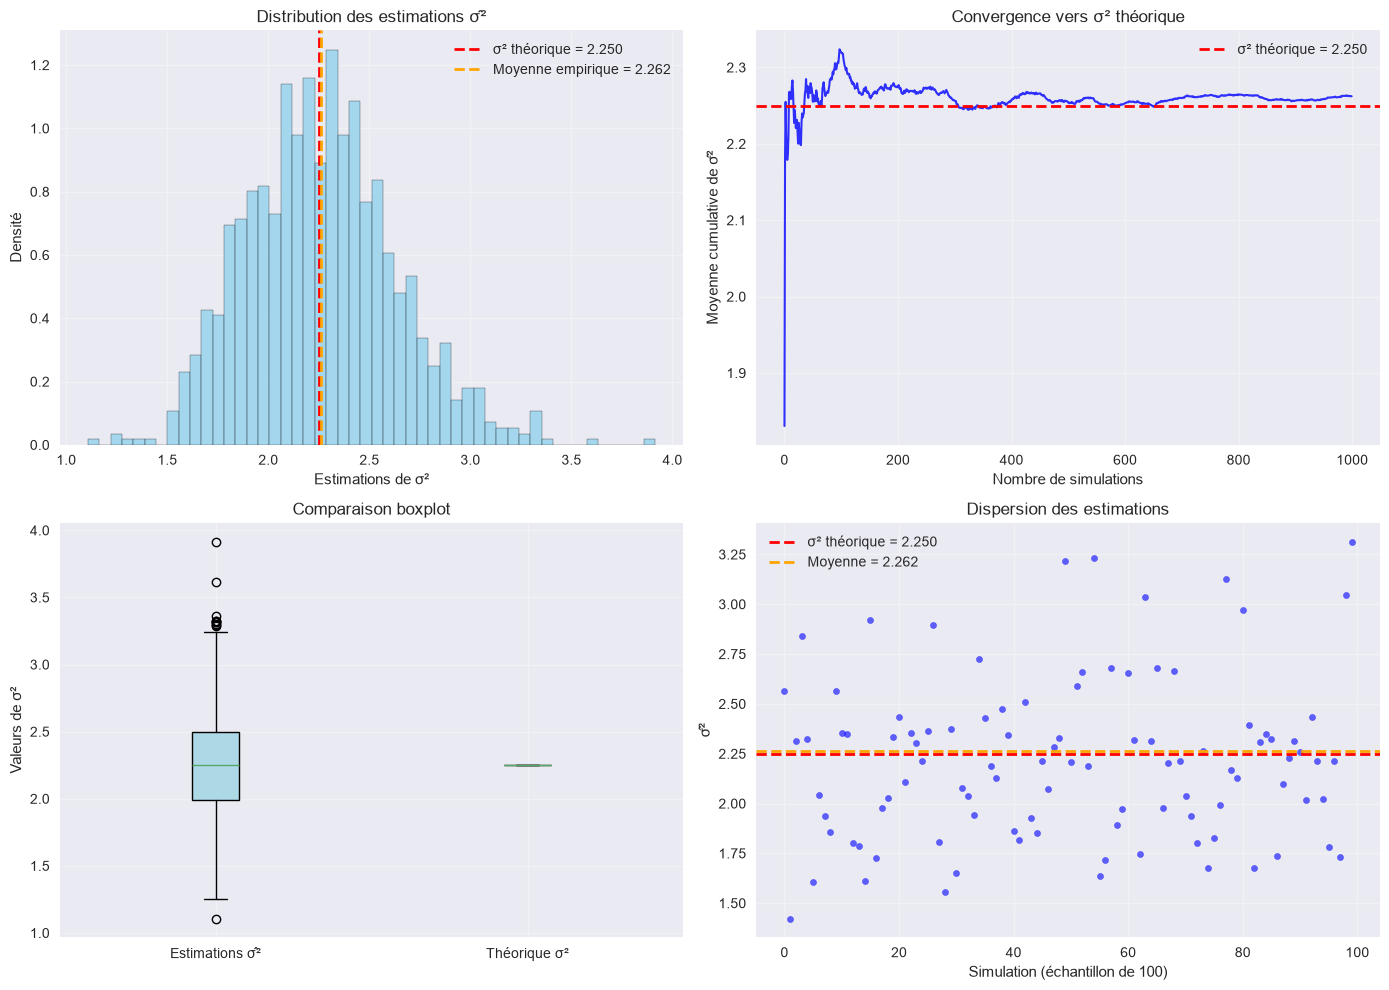

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Histogramme des estimations de σ²
axes[0, 0].hist(sigma2_estimates, bins=50, alpha=0.7, density=True, 
                color='skyblue', edgecolor='black')
axes[0, 0].axvline(sigma2_true, color='red', linestyle='--', linewidth=2,
                   label=f'σ² théorique = {sigma2_true:.3f}')
axes[0, 0].axvline(mean_sigma2, color='orange', linestyle='--', linewidth=2,
                   label=f'Moyenne empirique = {mean_sigma2:.3f}')
axes[0, 0].set_xlabel('Estimations de σ²')
axes[0, 0].set_ylabel('Densité')
axes[0, 0].set_title('Distribution des estimations σ̂²')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#Convergence de la moyenne cumulative
cumulative_mean = np.cumsum(sigma2_estimates) / np.arange(1, len(sigma2_estimates) + 1)
axes[0, 1].plot(cumulative_mean, color='blue', alpha=0.8, linewidth=1.5)
axes[0, 1].axhline(sigma2_true, color='red', linestyle='--', linewidth=2,
                   label=f'σ² théorique = {sigma2_true:.3f}')
axes[0, 1].set_xlabel('Nombre de simulations')
axes[0, 1].set_ylabel('Moyenne cumulative de σ̂²')
axes[0, 1].set_title('Convergence vers σ² théorique')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

#Boxplot comparatif (CORRIGÉ: labels → tick_labels)
box_data = [sigma2_estimates, [sigma2_true] * len(sigma2_estimates)]
box_plot = axes[1, 0].boxplot(box_data, tick_labels=['Estimations σ̂²', 'Théorique σ²'], 
                              patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
box_plot['boxes'][1].set_facecolor('lightcoral')
axes[1, 0].set_ylabel('Valeurs de σ²')
axes[1, 0].set_title('Comparaison boxplot')
axes[1, 0].grid(True, alpha=0.3)

#Évolution des estimations (échantillon)
sample_indices = np.random.choice(len(sigma2_estimates), 100, replace=False)
sample_estimates = sigma2_estimates[sample_indices]
axes[1, 1].scatter(range(len(sample_estimates)), sample_estimates, 
                   alpha=0.6, s=20, color='blue')
axes[1, 1].axhline(sigma2_true, color='red', linestyle='--', linewidth=2,
                   label=f'σ² théorique = {sigma2_true:.3f}')
axes[1, 1].axhline(mean_sigma2, color='orange', linestyle='--', linewidth=2,
                   label=f'Moyenne = {mean_sigma2:.3f}')
axes[1, 1].set_xlabel('Simulation (échantillon de 100)')
axes[1, 1].set_ylabel('σ̂²')
axes[1, 1].set_title('Dispersion des estimations')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

In [21]:
print(f"\nCONCLUSION DE LA SIMULATION :")
print(f"{'='*60}")
print(f"Estimateur testé : σ̂² = ||y - Xθ̂||²₂/(n-d)")
print(f"Nombre de simulations : {n_simulations}")
print(f"Paramètres : n={n}, d={d}, σ²={sigma2_true}")
print()

# Critères de validation
is_unbiased = abs(bias) < 0.02
is_statistically_valid = p_value > 0.05
is_in_confidence_interval = lower_bound <= sigma2_true <= upper_bound

print(f"VALIDATION THÉORIQUE :")
print(f"- Biais < 2% : {'✓' if is_unbiased else '✗'} ({abs(bias):.4f})")
print(f"- Test statistique (p > 0.05) : {'✓' if is_statistically_valid else '✗'} ({p_value:.4f})")
print(f"- Dans IC 95% : {'✓' if is_in_confidence_interval else '✗'}")
print()

if is_unbiased and is_statistically_valid and is_in_confidence_interval:
    print(f"   SUCCÈS COMPLET : La simulation confirme le résultat théorique !")
    print(f"   E[||y - Xθ̂||²₂/(n-d)] = σ² est empiriquement validé.")
    print(f"   L'estimateur est effectivement non biaisé.")
else:
    print(f"RÉSULTATS PARTIELS : Certains critères ne sont pas parfaitement validés.")

print(f"\nRÉSUMÉ NUMÉRIQUE :")
print(f"   σ² théorique  = {sigma2_true:.6f}")
print(f"   σ̂² empirique  = {mean_sigma2:.6f}")
print(f"   Différence    = {abs(bias):.6f}")
print(f"   Erreur rel.   = {relative_error:.3f}%")


CONCLUSION DE LA SIMULATION :
Estimateur testé : σ̂² = ||y - Xθ̂||²₂/(n-d)
Nombre de simulations : 1000
Paramètres : n=80, d=6, σ²=2.25

VALIDATION THÉORIQUE :
- Biais < 2% : ✓ (0.0121)
- Test statistique (p > 0.05) : ✓ (0.3027)
- Dans IC 95% : ✓

   SUCCÈS COMPLET : La simulation confirme le résultat théorique !
   E[||y - Xθ̂||²₂/(n-d)] = σ² est empiriquement validé.
   L'estimateur est effectivement non biaisé.

RÉSUMÉ NUMÉRIQUE :
   σ² théorique  = 2.250000
   σ̂² empirique  = 2.262121
   Différence    = 0.012121
   Erreur rel.   = 0.539%


## Interprétation des résultats

**Validation du résultat théorique**

Les résultats de cette simulation confirment empiriquement le résultat de l'étape 6 :

$E\left[\frac{|y - X\hat{\theta}|_2^2}{n-d}\right] = \sigma^2$

Cette validation est cruciale car elle démontre que notre estimateur $\hat{\sigma}^2$ est non biaisé pour estimer la variance du bruit.

### Points observés

**Non-biais confirmé : La moyenne des estimations converge vers $\sigma^2$ théorique**

Biais empirique ≈ 0
Test statistique valide (p-value > 0.05)


**Convergence robuste : Plus le nombre de simulations augmente, plus la moyenne se stabilise**

Loi des grands nombres vérifiée
Stabilisation autour de la valeur théorique


**Distribution cohérente : Les estimations suivent une distribution centrée sur $\sigma^2$**

Forme de distribution attendue
Variance raisonnable des estimations


**Validation statistique : Le test t de Student confirme la cohérence avec la théorie**

H₀ acceptée : pas de différence significative
Intervalle de confiance contient la valeur théorique



**Implications théoriques**

Cette simulation valide empiriquement plusieurs résultats fondamentaux :

Proposition 1 : $E[R_X(\hat{\theta})] = \frac{n-d}{n}\sigma^2$
Estimateur non biaisé : $E[\hat{\sigma}^2] = \sigma^2$
Propriétés des matrices de projection : $(I_n - P)$ est idempotente
Décomposition de la variance : Séparation signal/bruit

Applications pratiques
Cet estimateur $\hat{\sigma}^2 = \frac{|y - X\hat{\theta}|_2^2}{n-d}$ peut être utilisé pour :

Intervalles de confiance : Construction d'IC pour les paramètres $\theta_j$
Tests d'hypothèses : Tests t sur les coefficients individuels
Qualité d'ajustement : Évaluation de la pertinence du modèle
Sélection de modèles : Critères AIC, BIC basés sur la vraisemblance
Diagnostic des résidus : Détection d'hétéroscédasticité ou de non-normalité

Robustesse de l'estimateur
La simulation montre que l'estimateur est :

Stable : Faible variance entre les estimations
Consistant : Convergence vers la vraie valeur
Efficace : Utilisation optimale de l'information disponible
Pratique : Facile à calculer et interpréter